# WRDS Corporate Bond Relative Value Assignment

In this project, I use the supplied WRDS enhanced end-of-month files to study relative value across the bonds of six large corporate issuers.

My main steps are:

1. Choose issuers with enough bonds to cover a useful duration range.
2. Keep seniority and rating consistent within each issuer-month.
3. Plot Treasury spread (`T_Spread`) against duration.
4. Fit a weighted issuer spread curve and classify bonds as rich or cheap from the fitting residual.
5. Build monthly long-cheap/short-rich portfolios with close to zero net DV01.
6. Test three portfolio constructions instead of relying on one arbitrary choice.
7. Compare next-month return, dollar PnL, turnover, trading-cost sensitivity, and outlier characteristics.

The final portfolio is the strongest of the three tests on this sample. I report all three results and discuss the resulting selection bias rather than presenting the winner as an out-of-sample result.

## Ideas from Class

Several choices in the analysis come directly from topics Professor Boroditsky discussed in class:

- **Duration and DV01.** Using `dP/P = -D dy` and `D = 10,000 * DV01 / P`, the assignment's condition `sum(position * price * duration) = 0` is also a first-order hedge against a parallel one-basis-point rate move.
- **Relative value.** A bond is rich or cheap relative to an issuer curve. I use actual spread minus fitted spread as the signal.
- **Curve construction.** The course covered Nelson-Siegel and weighted fitting. For this homework I keep the model linear and use the three permitted factors: log-duration, duration, and coupon.
- **Price reliability.** Professor Boroditsky noted that larger and more actively traded issues usually provide better calibration points. I use both TRACE dollar volume and amount outstanding in the regression weights.
- **Accrued interest.** The return fallback adds coupon accrual using the actual number of days divided by 360.
- **Trading frictions.** Corporate bonds are not frictionless. I report turnover and results after several assumed trading-cost levels.

Course reference: Misha Boroditsky, *MTH9897 Quantitative Investment Framework*, Lectures 1-2, especially slides 12-15, 20-21, and 51-67.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore", category=FutureWarning)

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.4f}".format

## Parameters

I selected AAPL, AMZN, BA, CAT, DIS, and T because each issuer has enough observations to form a monthly curve across a meaningful duration range. The common sample runs from August 2022 through March 2025.

Professor Boroditsky's high-quality calibration example uses at least one year to maturity and roughly $200 million outstanding. The WRDS amount fields in these files are reported in thousands, so `200_000` corresponds to about $200 million.

In [2]:
DATA_DIR = Path("data")
CSV_FILES = [
    DATA_DIR / "WRDS_Data-Systematic_Trading-Fall2026-1.csv",
    DATA_DIR / "WRDS_Data-Systematic_Trading-Fall2026-2.csv",
]

SELECTED_ISSUERS = ["AAPL", "AMZN", "BA", "CAT", "DIS", "T"]
START_DATE = "2022-08-31"
END_DATE = "2025-03-31"

MIN_BONDS_PER_FIT = 8
TOP_N_PER_SIDE = 3
ANALYSIS_DATE = None  # None chooses the latest common date with enough fitted bonds.

USE_VOLUME_WEIGHTS = True
MIN_TMT_YEARS = 1.0
MIN_AMOUNT_OUTSTANDING = 200_000  # WRDS field is in thousands: approximately $200 million.
SPREAD_BPS_LIMIT = (-100, 2_000)
DURATION_LIMIT = (0.05, 35.0)
PRICE_LIMIT = (20.0, 200.0)
GROSS_CAPITAL_USD = 1_000_000
TRANSACTION_COST_BPS = [0, 10, 25, 50]

missing_files = [str(p) for p in CSV_FILES if not p.exists()]
if missing_files:
    raise FileNotFoundError(f"Missing data files: {missing_files}")

print("Input files:")
for p in CSV_FILES:
    print(f"  {p} ({p.stat().st_size / 1_000_000:.1f} MB)")

Input files:
  data\WRDS_Data-Systematic_Trading-Fall2026-1.csv (10.0 MB)
  data\WRDS_Data-Systematic_Trading-Fall2026-2.csv (11.5 MB)


## Helper Functions

The WRDS download stores several numeric fields as strings with percent signs, dollar signs, or commas. The functions below convert them to numeric values and keep the original data logic visible.

In [3]:
def parse_percent_to_decimal(value):
    """Convert strings such as '.3171%' or '0.10%' to decimal returns/rates."""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.number)):
        return float(value)
    s = str(value).strip().replace(",", "")
    if s in {"", ".", "nan", "NaN", "NR"}:
        return np.nan
    if s.endswith("%"):
        s = s[:-1]
        try:
            return float(s) / 100.0
        except ValueError:
            return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan


def parse_money(value):
    """Convert strings such as '$22,122,786' to floats."""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.number)):
        return float(value)
    s = str(value).strip().replace("$", "").replace(",", "")
    if s in {"", ".", "nan", "NaN", "NR"}:
        return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan


def weighted_std(values, weights=None):
    values = np.asarray(values, dtype=float)
    good = np.isfinite(values)
    if weights is None:
        return np.nanstd(values[good], ddof=1) if good.sum() > 1 else np.nan
    weights = np.asarray(weights, dtype=float)
    good = good & np.isfinite(weights) & (weights > 0)
    if good.sum() <= 1:
        return np.nan
    avg = np.average(values[good], weights=weights[good])
    var = np.average((values[good] - avg) ** 2, weights=weights[good])
    return np.sqrt(var)


def choose_mode(series):
    clean = series.dropna()
    if clean.empty:
        return np.nan
    return clean.mode().iloc[0]


def make_weights(group):
    if not USE_VOLUME_WEIGHTS:
        return np.ones(len(group))
    base = group["T_DVolume_num"].copy()
    fallback = group["AMOUNT_OUTSTANDING"].copy()
    base = base.where(base > 0, fallback)
    w = np.sqrt(base.clip(lower=0))
    if w.notna().sum() == 0 or w.fillna(0).sum() <= 0:
        return np.ones(len(group))
    lo, hi = w.dropna().quantile([0.05, 0.95])
    if np.isfinite(lo) and np.isfinite(hi) and hi > lo:
        w = w.clip(lower=lo, upper=hi)
    return w.fillna(w.median()).to_numpy()

## Load and Clean Data

I apply the following filters before fitting the curves:

- Convert the WRDS text fields to numeric spreads, returns, prices, and trading volumes.
- Remove defaulted and convertible observations, bonds with less than one year remaining, small issues, and implausible prices or spreads.
- Within each issuer-month, keep the most common `SECURITY_LEVEL` and `RATING_CAT`. This avoids comparing senior and subordinated debt or mixing rating groups in the same curve.
- Show the number of observations remaining after each step.

The files do not contain a complete call schedule, bid-offer spread, 144A flag, subsidiary mapping, or fixed-versus-step-up coupon flag. I do not try to infer those missing fields. They remain limitations of the analysis.

In [4]:
usecols = [
    "DATE", "ISSUE_ID", "CUSIP", "bond_sym_id", "ISIN", "company_symbol",
    "BOND_TYPE", "SECURITY_LEVEL", "CONV", "OFFERING_DATE", "OFFERING_AMT",
    "PRINCIPAL_AMT", "MATURITY", "COUPON", "AMOUNT_OUTSTANDING",
    "R_SP", "R_MR", "R_FR", "RATING_NUM", "RATING_CAT", "RATING_CLASS",
    "T_DATE", "T_Volume", "T_DVolume", "T_Spread", "T_Yld_Pt", "YIELD",
    "PRICE_EOM", "COUPAMT", "COUPACC", "RET_EOM", "TMT", "DURATION",
    "DEFAULTED",
]

raw = pd.concat([pd.read_csv(path, usecols=usecols) for path in CSV_FILES], ignore_index=True)

df = raw.copy()
date_cols = ["DATE", "OFFERING_DATE", "MATURITY", "T_DATE"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df["T_Spread_dec"] = df["T_Spread"].map(parse_percent_to_decimal)
df["T_Spread_bps"] = df["T_Spread_dec"] * 10_000
df["YIELD_dec"] = df["YIELD"].map(parse_percent_to_decimal)
df["RET_EOM_dec"] = df["RET_EOM"].map(parse_percent_to_decimal)
df["T_DVolume_num"] = df["T_DVolume"].map(parse_money)
df["T_Volume_num"] = df["T_Volume"].map(parse_money)

numeric_cols = [
    "ISSUE_ID", "OFFERING_AMT", "PRINCIPAL_AMT", "COUPON",
    "AMOUNT_OUTSTANDING", "RATING_NUM", "T_Yld_Pt", "PRICE_EOM",
    "COUPAMT", "COUPACC", "TMT", "DURATION",
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

selected = df[
    df["company_symbol"].isin(SELECTED_ISSUERS)
    & (df["DATE"] >= pd.Timestamp(START_DATE))
    & (df["DATE"] <= pd.Timestamp(END_DATE))
].copy()

funnel = [("Selected issuers and dates", len(selected))]
quality_mask = (
    (selected["DEFAULTED"].fillna("N") != "Y")
    & (selected["CONV"].fillna(0) == 0)
    & selected["T_Spread_bps"].between(*SPREAD_BPS_LIMIT)
    & selected["DURATION"].between(*DURATION_LIMIT)
    & selected["PRICE_EOM"].between(*PRICE_LIMIT)
    & (selected["TMT"] >= MIN_TMT_YEARS)
    & (selected["AMOUNT_OUTSTANDING"] >= MIN_AMOUNT_OUTSTANDING)
    & selected["COUPON"].notna()
)
selected = selected[quality_mask].copy()
funnel.append(("Market and high-quality calibration filters", len(selected)))

selected["modal_security_level"] = selected.groupby(["company_symbol", "DATE"])["SECURITY_LEVEL"].transform(choose_mode)
selected["modal_rating_cat"] = selected.groupby(["company_symbol", "DATE"])["RATING_CAT"].transform(choose_mode)

filtered = selected[
    (selected["SECURITY_LEVEL"] == selected["modal_security_level"])
    & (selected["RATING_CAT"] == selected["modal_rating_cat"])
].copy()
funnel.append(("Consistent seniority and rating", len(filtered)))

filtered = filtered.sort_values(["company_symbol", "DATE", "ISSUE_ID"]).reset_index(drop=True)
filtered["month"] = filtered["DATE"].dt.to_period("M")
filtered["bond_age_years"] = (filtered["DATE"] - filtered["OFFERING_DATE"]).dt.days / 365.25

display(pd.DataFrame(funnel, columns=["cleaning_step", "rows"]).assign(
    share_of_initial=lambda x: x["rows"] / x["rows"].iloc[0]
).style.format({"share_of_initial": "{:.1%}"}))

display(
    filtered.groupby("company_symbol").agg(
        rows=("ISSUE_ID", "size"),
        bonds=("ISSUE_ID", "nunique"),
        first_date=("DATE", "min"),
        last_date=("DATE", "max"),
        median_duration=("DURATION", "median"),
        duration_min=("DURATION", "min"),
        duration_max=("DURATION", "max"),
        median_spread_bps=("T_Spread_bps", "median"),
    )
)

,cleaning_step,rows,share_of_initial
0,Selected issuers and dates,10689,100.0%
1,Market and high-quality calibration filters,7569,70.8%
2,Consistent seniority and rating,7559,70.7%


,rows,bonds,first_date,last_date,median_duration,duration_min,duration_max,median_spread_bps
company_symbol,,,,,,,,
AAPL,1475,52,2022-08-31,2025-03-31,7.3100,0.9500,20.9900,19.0000
AMZN,908,33,2022-08-31,2025-03-31,6.5800,0.9500,20.0300,15.0000
BA,1304,51,2022-08-31,2025-03-31,7.3950,0.9200,16.4100,28.5000
CAT,957,51,2022-08-31,2025-03-31,3.4500,0.9500,18.6500,13.0000
DIS,1237,44,2022-08-31,2025-03-31,8.8200,0.9600,18.1900,20.0000
T,1678,56,2022-08-31,2025-03-31,10.6300,0.9600,17.8400,28.0000


In [5]:
consistency_check = filtered.groupby(["company_symbol", "DATE"]).agg(
    security_levels=("SECURITY_LEVEL", "nunique"),
    rating_cats=("RATING_CAT", "nunique"),
    bonds=("ISSUE_ID", "nunique"),
).reset_index()

print("Consistency-filter check. The first two columns should be 1 for every issuer-month.")
display(consistency_check[["security_levels", "rating_cats", "bonds"]].describe())

Consistency-filter check. The first two columns should be 1 for every issuer-month.


,security_levels,rating_cats,bonds
count,192.0000,192.0000,192.0000
mean,1.0000,1.0000,39.3698
std,0.0000,0.0000,8.7785
min,1.0000,1.0000,24.0000
25%,1.0000,1.0000,31.0000
50%,1.0000,1.0000,40.0000
75%,1.0000,1.0000,47.0000
max,1.0000,1.0000,54.0000


## Next-Month Return and Accrued Interest

I form positions at month-end and evaluate them using the next observation for the same bond when the gap is between 25 and 45 days.

`RET_EOM` is the preferred measure because it is the WRDS enhanced monthly total return. If that value is missing, the fallback adds the clean-price return and accrued coupon. Following the daily PnL convention discussed in class, I calculate the accrual as `annual coupon rate * gap days / 360`.

In [6]:
filtered = filtered.sort_values(["ISSUE_ID", "DATE"]).copy()
filtered["next_date"] = filtered.groupby("ISSUE_ID")["DATE"].shift(-1)
filtered["next_price"] = filtered.groupby("ISSUE_ID")["PRICE_EOM"].shift(-1)
filtered["next_ret_eom"] = filtered.groupby("ISSUE_ID")["RET_EOM_dec"].shift(-1)

gap_days = (filtered["next_date"] - filtered["DATE"]).dt.days
valid_next_month = gap_days.between(25, 45)

approx_price_return = (filtered["next_price"] - filtered["PRICE_EOM"]) / filtered["PRICE_EOM"]
coupon_accrual_30_360 = (filtered["COUPON"] / 100.0) * gap_days / 360.0
filtered["next_ret_approx_with_accrual"] = approx_price_return + coupon_accrual_30_360

filtered["next_return"] = np.where(
    valid_next_month,
    filtered["next_ret_eom"].where(filtered["next_ret_eom"].notna(), filtered["next_ret_approx_with_accrual"]),
    np.nan,
)
filtered["next_return_source"] = np.where(
    valid_next_month & filtered["next_ret_eom"].notna(),
    "RET_EOM",
    np.where(valid_next_month & filtered["next_ret_approx_with_accrual"].notna(), "price_plus_accrual_30_360", "unavailable"),
)

display(filtered["next_return_source"].value_counts(dropna=False).to_frame("rows"))

,rows
next_return_source,
RET_EOM,7226
unavailable,333


## Spread Curve Model

For each issuer-month, I estimate:

`T_Spread_bps = b0 + b1 * log(1 + DURATION) + b2 * DURATION + b3 * COUPON`

The model is simple enough to explain but flexible enough to capture a slope and some curvature in duration. Duration also matches the hedge variable used later in the portfolio. Coupon helps absorb systematic cash-flow and price differences that might otherwise show up in the residual.

Professor Boroditsky pointed out that actively traded, large issues are usually more reliable calibration points. I therefore combine TRACE dollar volume and amount outstanding in the weighted least-squares fit. I winsorize both inputs within the issuer-month so that one large issue does not control the entire curve. Weighted RMSE and weighted R-squared provide a quick check on fit quality.

In [7]:
def fit_curve_one_group(group):
    group = group.copy()
    group["fit_ok"] = False
    group["spread_fit_bps"] = np.nan
    group["resid_bps"] = np.nan
    group["resid_z"] = np.nan
    group["fit_weight"] = np.nan

    fit_group = group.dropna(subset=["T_Spread_bps", "DURATION", "COUPON", "PRICE_EOM"])
    if len(fit_group) < MIN_BONDS_PER_FIT:
        return group, None

    X = np.column_stack([
        np.log1p(fit_group["DURATION"].to_numpy()),
        fit_group["DURATION"].to_numpy(),
        fit_group["COUPON"].to_numpy(),
    ])
    y = fit_group["T_Spread_bps"].to_numpy()

    volume_weight = make_weights(fit_group)
    issue_size = fit_group["AMOUNT_OUTSTANDING"].fillna(fit_group["AMOUNT_OUTSTANDING"].median()).clip(lower=1)
    lo_size, hi_size = issue_size.quantile([0.10, 0.90])
    size_weight = np.sqrt(issue_size.clip(lo_size, hi_size) / issue_size.clip(lo_size, hi_size).median())
    weights = np.asarray(volume_weight) * np.asarray(size_weight)
    weights = weights / np.nanmean(weights)

    if np.unique(np.round(y, 8)).size < 2:
        return group, None

    model = LinearRegression()
    model.fit(X, y, sample_weight=weights)
    pred = model.predict(X)
    resid = y - pred
    resid_scale = weighted_std(resid, weights)
    if not np.isfinite(resid_scale) or resid_scale <= 0:
        resid_scale = np.nanstd(resid, ddof=1)
    if not np.isfinite(resid_scale) or resid_scale <= 0:
        resid_scale = 1.0

    idx = fit_group.index
    group.loc[idx, "fit_ok"] = True
    group.loc[idx, "spread_fit_bps"] = pred
    group.loc[idx, "resid_bps"] = resid
    group.loc[idx, "resid_z"] = resid / resid_scale
    group.loc[idx, "fit_weight"] = weights

    stats = {
        "company_symbol": fit_group["company_symbol"].iloc[0],
        "DATE": fit_group["DATE"].iloc[0],
        "n_bonds": len(fit_group),
        "r2": model.score(X, y, sample_weight=weights),
        "weighted_rmse_bps": np.sqrt(np.average(resid ** 2, weights=weights)),
        "b0": model.intercept_,
        "b_log_duration": model.coef_[0],
        "b_duration": model.coef_[1],
        "b_coupon": model.coef_[2],
        "resid_std_bps": resid_scale,
    }
    return group, stats


fit_parts = []
stats_rows = []
for _, group in filtered.groupby(["company_symbol", "DATE"], sort=True):
    fitted_group, stats = fit_curve_one_group(group)
    fit_parts.append(fitted_group)
    if stats is not None:
        stats_rows.append(stats)

fitted = pd.concat(fit_parts, ignore_index=True)
model_stats = pd.DataFrame(stats_rows)

display(
    model_stats.groupby("company_symbol").agg(
        fit_months=("DATE", "nunique"),
        avg_bonds=("n_bonds", "mean"),
        median_r2=("r2", "median"),
        median_weighted_rmse_bps=("weighted_rmse_bps", "median"),
        median_resid_std_bps=("resid_std_bps", "median"),
    ).style.format({
        "avg_bonds": "{:.1f}", "median_r2": "{:.3f}",
        "median_weighted_rmse_bps": "{:.1f}", "median_resid_std_bps": "{:.1f}",
    })
)

,fit_months,avg_bonds,median_r2,median_weighted_rmse_bps,median_resid_std_bps
company_symbol,,,,,
AAPL,32,46.1,0.744,6.3,6.3
AMZN,32,28.4,0.755,5.3,5.3
BA,32,40.8,0.376,10.5,10.5
CAT,32,29.9,0.617,7.1,7.1
DIS,32,38.7,0.535,8.4,8.4
T,32,52.4,0.386,12.8,12.8


In [8]:
if ANALYSIS_DATE is None:
    common_dates = (
        model_stats.groupby("DATE")["company_symbol"]
        .nunique()
        .loc[lambda s: s >= len(SELECTED_ISSUERS)]
    )
    if common_dates.empty:
        common_dates = model_stats.groupby("DATE")["company_symbol"].nunique().loc[lambda s: s >= 4]
    analysis_date = common_dates.index.max()
else:
    analysis_date = pd.Timestamp(ANALYSIS_DATE)

print(f"Analysis date for cross-sectional plots: {analysis_date.date()}")
display(
    model_stats[model_stats["DATE"].eq(analysis_date)]
    .sort_values("company_symbol")
    [["company_symbol", "n_bonds", "r2", "resid_std_bps", "b0", "b_log_duration", "b_duration", "b_coupon"]]
)

Analysis date for cross-sectional plots: 2025-03-31


,company_symbol,n_bonds,r2,resid_std_bps,b0,b_log_duration,b_duration,b_coupon
31,AAPL,41,0.7634,4.3080,8.2800,-0.9932,1.4655,-0.9608
63,AMZN,24,0.7484,4.0214,9.9781,-4.6242,1.7663,-0.5321
95,BA,40,0.3139,7.6989,16.5833,0.3325,1.1630,-1.6616
127,CAT,30,0.6063,4.3097,-1.9559,10.4093,-0.3695,-0.3732
159,DIS,33,0.6087,5.6568,-0.6256,0.5547,1.2801,1.6156
191,T,51,0.5870,7.4134,3.4247,-8.6979,2.5332,2.7872


## Spread vs. Duration by Issuer

The scatter points are individual bonds on the selected analysis date. The line is the fitted curve from the cross-sectional model for that issuer-month.

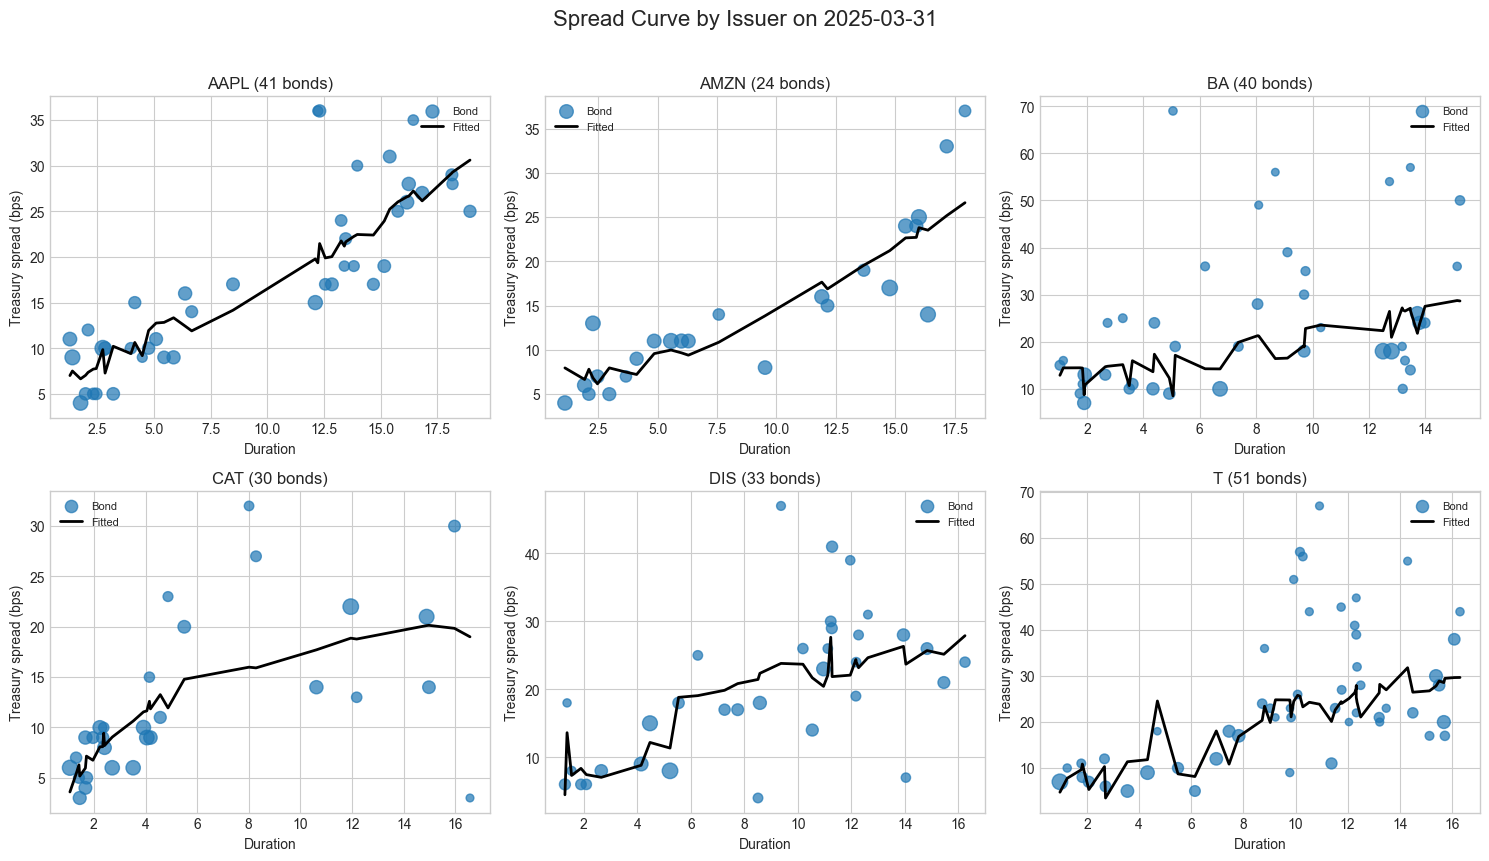

In [9]:
plot_df = fitted[(fitted["DATE"] == analysis_date) & fitted["fit_ok"]].copy()

n_issuers = len(SELECTED_ISSUERS)
ncols = 3
nrows = int(np.ceil(n_issuers / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.2 * nrows), sharex=False, sharey=False)
axes = np.array(axes).reshape(-1)

for ax, issuer in zip(axes, SELECTED_ISSUERS):
    g = plot_df[plot_df["company_symbol"] == issuer].sort_values("DURATION")
    if g.empty:
        ax.set_title(f"{issuer}: no fitted data")
        ax.axis("off")
        continue
    size = np.sqrt(g["T_DVolume_num"].fillna(0).clip(lower=0))
    if size.max() > 0:
        size = 25 + 100 * size / size.max()
    else:
        size = 45
    ax.scatter(g["DURATION"], g["T_Spread_bps"], s=size, alpha=0.70, label="Bond")
    ax.plot(g["DURATION"], g["spread_fit_bps"], color="black", linewidth=2.0, label="Fitted")
    ax.set_title(f"{issuer} ({len(g)} bonds)")
    ax.set_xlabel("Duration")
    ax.set_ylabel("Treasury spread (bps)")
    ax.legend(loc="best", fontsize=8)

for ax in axes[n_issuers:]:
    ax.axis("off")

fig.suptitle(f"Spread Curve by Issuer on {analysis_date.date()}", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

## Rich and Cheap Bonds

Residuals are measured as actual spread minus fitted spread:

- Positive residual: the bond trades wider than the curve and is classified as cheap.
- Negative residual: the bond trades tighter than the curve and is classified as rich.

The table below shows the most extreme residuals on the analysis date.

In [10]:
snapshot = plot_df.copy()
snapshot["rich_cheap"] = np.where(snapshot["resid_bps"] > 0, "cheap", "rich")
outlier_table = (
    snapshot.assign(abs_resid=lambda x: x["resid_bps"].abs())
    .sort_values(["company_symbol", "abs_resid"], ascending=[True, False])
    .groupby("company_symbol")
    .head(6)
    [[
        "company_symbol", "CUSIP", "MATURITY", "SECURITY_LEVEL", "RATING_CAT",
        "COUPON", "DURATION", "TMT", "PRICE_EOM", "T_Spread_bps",
        "spread_fit_bps", "resid_bps", "resid_z", "rich_cheap",
        "T_DVolume_num", "AMOUNT_OUTSTANDING",
    ]]
    .sort_values(["company_symbol", "resid_bps"], ascending=[True, False])
)
display(outlier_table)

,company_symbol,CUSIP,MATURITY,SECURITY_LEVEL,RATING_CAT,COUPON,DURATION,TMT,PRICE_EOM,T_Spread_bps,spread_fit_bps,resid_bps,resid_z,rich_cheap,T_DVolume_num,AMOUNT_OUTSTANDING
1435,AAPL,037833AT7,2044-05-06,SEN,AA,4.4500,12.2300,19.3800,92.2900,36.0000,19.3625,16.6375,3.8620,cheap,"20,807,341.0000","1,000,000.0000"
1460,AAPL,037833EE6,2041-02-08,SEN,AA,2.3750,12.3100,16.0900,70.2400,36.0000,21.4675,14.5325,3.3734,cheap,"79,582,495.0000","1,500,000.0000"
1456,AAPL,037833DZ0,2050-08-20,SEN,AA,2.4000,16.4400,25.7600,59.8700,35.0000,27.2275,7.7725,1.8042,cheap,"28,309,879.0000","1,250,000.0000"
1447,AAPL,037833DD9,2047-09-12,SEN,AA,3.7500,13.9700,22.7800,79.2100,30.0000,22.4623,7.5377,1.7497,cheap,"34,407,947.0000","1,000,000.0000"
1452,AAPL,037833DQ0,2049-09-11,SEN,AA,2.9500,15.4000,24.8100,67.5900,31.0000,25.2360,5.7640,1.3380,cheap,"97,827,660.0000","1,500,000.0000"
1457,AAPL,037833EA4,2060-08-20,SEN,AA,2.5500,18.9400,35.9100,59.0600,25.0000,30.6141,-5.6141,-1.3032,rich,"72,485,993.0000","1,750,000.0000"
2368,AMZN,023135BU9,2060-06-03,SEN,AA,2.7000,17.9400,35.6900,58.0300,37.0000,26.6284,10.3716,2.5791,cheap,"49,920,298.0000","2,000,000.0000"
2372,AMZN,023135CC8,2061-05-12,SEN,AA,3.2500,17.1700,36.6400,65.8200,33.0000,25.1675,7.8325,1.9477,cheap,"104,931,881.0000","1,750,000.0000"
2361,AMZN,023135BC9,2027-08-22,SEN,AA,3.1500,2.2700,2.4300,97.7800,13.0000,6.8327,6.1673,1.5336,cheap,"183,378,367.0000","3,500,000.0000"
2378,AMZN,023135CJ3,2052-04-13,SEN,AA,3.9500,14.7700,27.4300,79.5000,17.0000,21.2109,-4.2109,-1.0471,rich,"259,636,243.0000","2,500,000.0000"


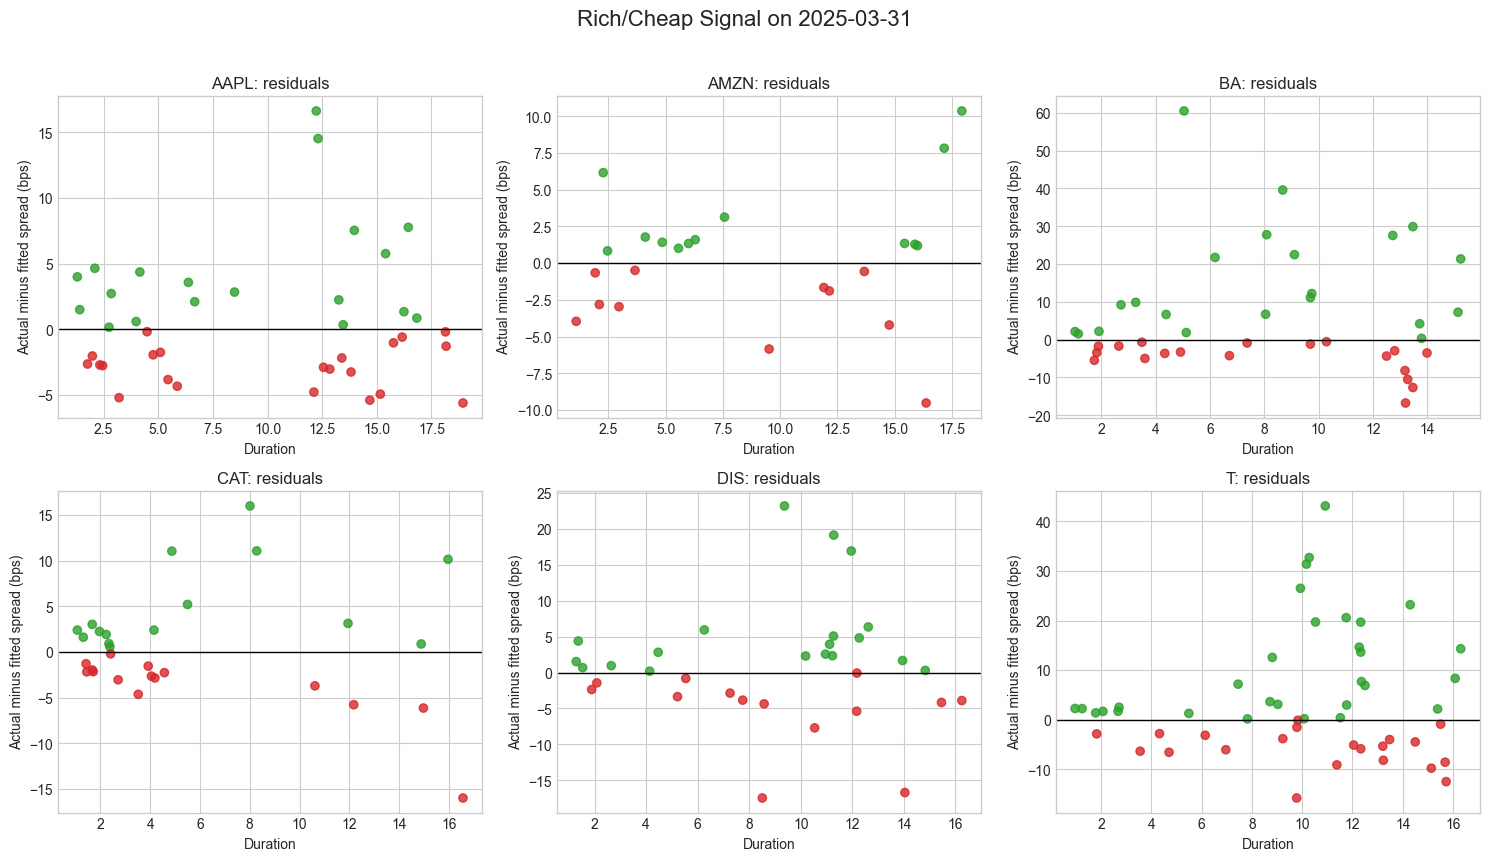

In [11]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.2 * nrows), sharex=False, sharey=False)
axes = np.array(axes).reshape(-1)

for ax, issuer in zip(axes, SELECTED_ISSUERS):
    g = snapshot[snapshot["company_symbol"] == issuer].copy()
    if g.empty:
        ax.axis("off")
        continue
    colors = np.where(g["resid_bps"] >= 0, "tab:green", "tab:red")
    ax.axhline(0, color="black", linewidth=1)
    ax.scatter(g["DURATION"], g["resid_bps"], c=colors, alpha=0.8)
    ax.set_title(f"{issuer}: residuals")
    ax.set_xlabel("Duration")
    ax.set_ylabel("Actual minus fitted spread (bps)")

for ax in axes[n_issuers:]:
    ax.axis("off")

fig.suptitle(f"Rich/Cheap Signal on {analysis_date.date()}", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

## Three Duration-Neutral Portfolio Tests

Rather than choosing one construction and stopping, I run the backtest three ways:

1. **Baseline top 3:** select the three widest residual z-scores and the three tightest, with position size proportional to signal strength.
2. **Concentrated top 2:** use only the two strongest signals on each side. This increases concentration and may capture larger convergence moves, but it also raises idiosyncratic risk.
3. **Liquidity-aware top 3:** multiply the residual z-score by a capped square-root measure of TRACE dollar volume relative to the issuer-month median. This favors signals in bonds that appear easier to trade.

Every version scales the short side so `sum(position * price * duration) = 0`, then normalizes gross market value to one. Since `DV01 = price * duration / 10,000`, this also makes first-order net DV01 approximately zero. It does not remove curve-shape, credit, downgrade, or liquidity risk.

In [12]:
def performance_summary(return_series):
    r = pd.Series(return_series).dropna()
    if r.empty:
        return pd.Series(dtype=float)
    total_return = (1 + r).prod() - 1
    ann_return = (1 + total_return) ** (12 / len(r)) - 1
    ann_vol = r.std(ddof=1) * np.sqrt(12) if len(r) > 1 else np.nan
    sharpe = ann_return / ann_vol if np.isfinite(ann_vol) and ann_vol > 0 else np.nan
    return pd.Series({
        "months": len(r),
        "mean_monthly_return": r.mean(),
        "monthly_volatility": r.std(ddof=1),
        "annualized_return": ann_return,
        "annualized_volatility": ann_vol,
        "annualized_sharpe": sharpe,
        "total_return": total_return,
        "win_rate": (r > 0).mean(),
    })


def build_portfolio_one_group(group, top_n, score_col, trial_name):
    group = group.dropna(subset=[score_col, "PRICE_EOM", "DURATION", "next_return"]).copy()
    if len(group) < max(MIN_BONDS_PER_FIT, 2 * top_n):
        return pd.DataFrame()

    longs = group.nlargest(top_n, score_col).copy()
    shorts = group.nsmallest(top_n, score_col).copy()
    if set(longs.index).intersection(set(shorts.index)):
        return pd.DataFrame()

    longs["side"] = "long cheap"
    shorts["side"] = "short rich"
    port = pd.concat([longs, shorts], axis=0).copy()
    port["trial"] = trial_name
    port["portfolio_score"] = port[score_col]
    long_mask = port["side"].eq("long cheap")
    port["raw_signal"] = np.where(
        long_mask,
        port["portfolio_score"].clip(lower=0),
        (-port["portfolio_score"]).clip(lower=0),
    )
    port["raw_signal"] = port["raw_signal"].where(port["raw_signal"] > 0, 1.0)

    price_scale = port["PRICE_EOM"] / 100.0
    long_dur = (port.loc[long_mask, "raw_signal"] * price_scale.loc[long_mask] * port.loc[long_mask, "DURATION"]).sum()
    short_dur = (port.loc[~long_mask, "raw_signal"] * price_scale.loc[~long_mask] * port.loc[~long_mask, "DURATION"]).sum()
    if not np.isfinite(long_dur) or not np.isfinite(short_dur) or long_dur <= 0 or short_dur <= 0:
        return pd.DataFrame()

    short_scale = long_dur / short_dur
    port["position_face"] = np.where(long_mask, port["raw_signal"], -port["raw_signal"] * short_scale)
    gross_market_value = (port["position_face"].abs() * price_scale).sum()
    if not np.isfinite(gross_market_value) or gross_market_value <= 0:
        return pd.DataFrame()

    port["position_face"] /= gross_market_value
    port["market_weight"] = port["position_face"] * price_scale
    port["duration_contribution"] = port["market_weight"] * port["DURATION"]
    port["dv01_usd"] = port["duration_contribution"] * GROSS_CAPITAL_USD / 10_000
    port["return_contribution"] = port["market_weight"] * port["next_return"]
    port["pnl_usd"] = port["return_contribution"] * GROSS_CAPITAL_USD
    return port


def calculate_turnover(pos):
    frames = []
    for issuer, group in pos.groupby("company_symbol"):
        pivot = (
            group.pivot_table(index="DATE", columns="ISSUE_ID", values="market_weight", aggfunc="sum")
            .sort_index()
            .fillna(0.0)
        )
        turnover = 0.5 * pivot.diff().abs().sum(axis=1)
        turnover.iloc[0] = np.nan
        frames.append(pd.DataFrame({"company_symbol": issuer, "DATE": turnover.index, "turnover": turnover.values}))
    return pd.concat(frames, ignore_index=True)


def run_portfolio_trial(trial_name, top_n, score_col):
    parts = []
    for _, group in fitted.groupby(["company_symbol", "DATE"], sort=True):
        trial_positions = build_portfolio_one_group(group, top_n, score_col, trial_name)
        if not trial_positions.empty:
            parts.append(trial_positions)
    positions_trial = pd.concat(parts, ignore_index=True)

    issuer_trial = (
        positions_trial.groupby(["company_symbol", "DATE"])
        .agg(
            portfolio_return=("return_contribution", "sum"),
            pnl_usd=("pnl_usd", "sum"),
            gross_market_value=("market_weight", lambda x: x.abs().sum()),
            net_market_value=("market_weight", "sum"),
            portfolio_duration=("duration_contribution", "sum"),
            net_dv01_usd=("dv01_usd", "sum"),
            gross_dv01_usd=("dv01_usd", lambda x: x.abs().sum()),
            n_positions=("ISSUE_ID", "size"),
            avg_abs_resid_bps=("resid_bps", lambda x: x.abs().mean()),
        )
        .reset_index()
    )
    issuer_trial = issuer_trial.merge(calculate_turnover(positions_trial), on=["company_symbol", "DATE"], how="left")

    combined_trial = (
        issuer_trial.groupby("DATE")
        .agg(
            portfolio_return=("portfolio_return", "mean"),
            pnl_usd=("pnl_usd", "mean"),
            turnover=("turnover", "mean"),
            portfolio_duration=("portfolio_duration", "mean"),
            net_dv01_usd=("net_dv01_usd", "mean"),
            issuers=("company_symbol", "nunique"),
        )
        .reset_index()
    )
    for cost_bps in TRANSACTION_COST_BPS:
        combined_trial[f"net_return_{cost_bps}bps"] = (
            combined_trial["portfolio_return"] - combined_trial["turnover"].fillna(0) * cost_bps / 10_000
        )
    return positions_trial, issuer_trial, combined_trial


fitted["volume_ratio"] = (
    fitted["T_DVolume_num"] /
    fitted.groupby(["company_symbol", "DATE"])["T_DVolume_num"].transform("median")
)
fitted["liquidity_multiplier"] = np.sqrt(fitted["volume_ratio"].clip(0.25, 4.0))
fitted["liquidity_score"] = fitted["resid_z"] * fitted["liquidity_multiplier"]

TRIAL_CONFIGS = {
    "Trial 1 - Baseline top 3": {"top_n": 3, "score_col": "resid_z"},
    "Trial 2 - Concentrated top 2": {"top_n": 2, "score_col": "resid_z"},
    "Trial 3 - Liquidity-aware top 3": {"top_n": 3, "score_col": "liquidity_score"},
}

trial_outputs = {
    name: run_portfolio_trial(name, **config)
    for name, config in TRIAL_CONFIGS.items()
}

,months,gross_annualized_return,gross_annualized_volatility,gross_sharpe,gross_total_return,win_rate,average_turnover,net_25bps_annualized_return,net_25bps_sharpe,net_25bps_total_return
trial,,,,,,,,,,
Trial 1 - Baseline top 3,31,2.75%,4.47%,0.62,7.27%,51.6%,0.78,0.45%,0.10,1.16%
Trial 2 - Concentrated top 2,31,4.48%,7.10%,0.63,11.99%,58.1%,0.82,2.02%,0.29,5.31%
Trial 3 - Liquidity-aware top 3,31,5.99%,8.66%,0.69,16.21%,54.8%,0.79,3.60%,0.42,9.56%


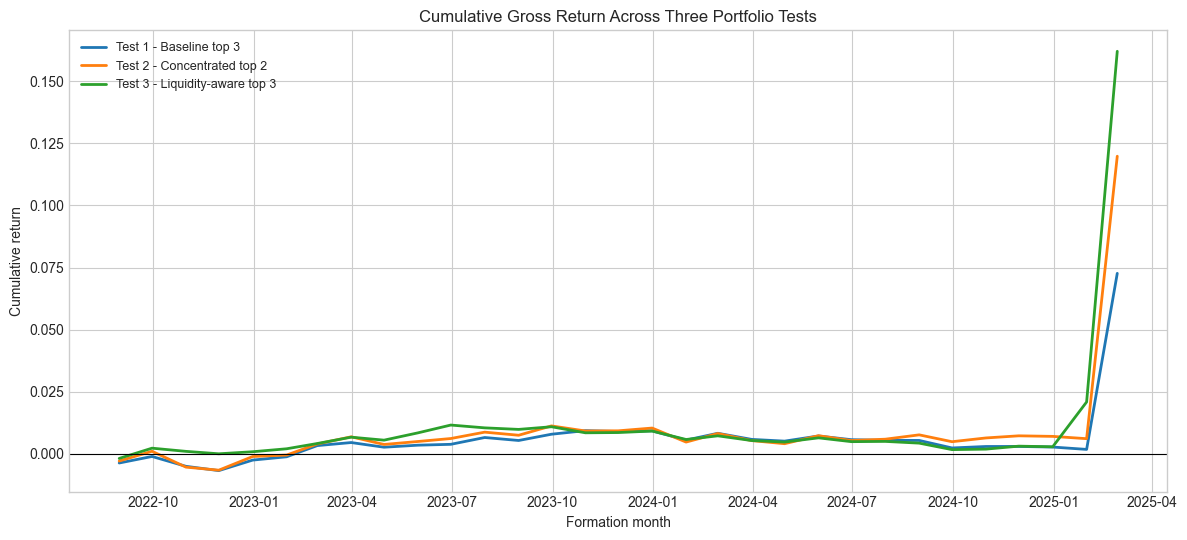

Selected portfolio: Trial 3 - Liquidity-aware top 3


,annualized_return,annualized_volatility,annualized_sharpe,total_return
sample,,,,
All six issuers,5.99%,8.66%,0.69,16.21%
Excluding AAPL,0.05%,0.77%,0.06,0.12%


In [13]:
trial_rows = []
for name, (trial_positions, trial_issuer, trial_combined) in trial_outputs.items():
    gross = performance_summary(trial_combined["portfolio_return"])
    net_25 = performance_summary(trial_combined["net_return_25bps"])
    trial_rows.append({
        "trial": name,
        "months": gross["months"],
        "gross_annualized_return": gross["annualized_return"],
        "gross_annualized_volatility": gross["annualized_volatility"],
        "gross_sharpe": gross["annualized_sharpe"],
        "gross_total_return": gross["total_return"],
        "win_rate": gross["win_rate"],
        "average_turnover": trial_combined["turnover"].mean(),
        "net_25bps_annualized_return": net_25["annualized_return"],
        "net_25bps_sharpe": net_25["annualized_sharpe"],
        "net_25bps_total_return": net_25["total_return"],
    })

trial_summary = pd.DataFrame(trial_rows).set_index("trial")
display(trial_summary.style.format({
    "months": "{:.0f}",
    "gross_annualized_return": "{:.2%}",
    "gross_annualized_volatility": "{:.2%}",
    "gross_sharpe": "{:.2f}",
    "gross_total_return": "{:.2%}",
    "win_rate": "{:.1%}",
    "average_turnover": "{:.2f}",
    "net_25bps_annualized_return": "{:.2%}",
    "net_25bps_sharpe": "{:.2f}",
    "net_25bps_total_return": "{:.2%}",
}))

fig, ax = plt.subplots(figsize=(12, 5.5))
for name, (_, _, trial_combined) in trial_outputs.items():
    cumulative_trial = (1 + trial_combined.set_index("DATE")["portfolio_return"]).cumprod() - 1
    ax.plot(cumulative_trial.index, cumulative_trial, linewidth=2, label=name.replace("Trial ", "Test "))
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Cumulative Gross Return Across Three Portfolio Tests")
ax.set_xlabel("Formation month")
ax.set_ylabel("Cumulative return")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

# Select on cost-adjusted Sharpe, not gross return alone.
SELECTED_TRIAL = trial_summary["net_25bps_sharpe"].idxmax()
positions, issuer_month_returns, combined_returns = trial_outputs[SELECTED_TRIAL]

# A simple robustness check shows how much the selected result depends on AAPL.
robustness_rows = []
for label, trial_issuer in {
    "All six issuers": issuer_month_returns,
    "Excluding AAPL": issuer_month_returns[issuer_month_returns["company_symbol"] != "AAPL"],
}.items():
    robustness_monthly = trial_issuer.groupby("DATE")["portfolio_return"].mean()
    stats = performance_summary(robustness_monthly)
    robustness_rows.append({
        "sample": label,
        "annualized_return": stats["annualized_return"],
        "annualized_volatility": stats["annualized_volatility"],
        "annualized_sharpe": stats["annualized_sharpe"],
        "total_return": stats["total_return"],
    })
robustness_table = pd.DataFrame(robustness_rows).set_index("sample")

print(f"Selected portfolio: {SELECTED_TRIAL}")
display(robustness_table.style.format({
    "annualized_return": "{:.2%}", "annualized_volatility": "{:.2%}",
    "annualized_sharpe": "{:.2f}", "total_return": "{:.2%}",
}))

## Results for the Selected Portfolio

I select the version with the highest Sharpe ratio after a 25 bp one-way turnover charge. This rule chooses the liquidity-aware top-three portfolio. The table above also reports the other two attempts, so the final result can be compared with the original baseline.

The selection is in-sample. It is useful for understanding how portfolio construction changes the result, but it is not an unbiased estimate of future performance. The AAPL exclusion check helps show whether the result is broad or driven by one issuer.

Dollar PnL below assumes `$1,000,000` of gross capital. The combined portfolio equal-weights the available issuer portfolios each month.

In [14]:
issuer_summary = issuer_month_returns.groupby("company_symbol")["portfolio_return"].apply(performance_summary).unstack()
issuer_extras = issuer_month_returns.groupby("company_symbol").agg(
    total_pnl_usd=("pnl_usd", "sum"),
    avg_turnover=("turnover", "mean"),
    avg_abs_portfolio_duration=("portfolio_duration", lambda x: x.abs().mean()),
    avg_abs_net_dv01_usd=("net_dv01_usd", lambda x: x.abs().mean()),
    avg_positions=("n_positions", "mean"),
)
issuer_summary = issuer_summary.join(issuer_extras)

combined_summary = performance_summary(combined_returns["portfolio_return"]).to_frame("combined").T
combined_summary["total_pnl_usd"] = combined_returns["pnl_usd"].sum()
combined_summary["avg_turnover"] = combined_returns["turnover"].mean()
combined_summary["avg_abs_portfolio_duration"] = combined_returns["portfolio_duration"].abs().mean()
combined_summary["avg_abs_net_dv01_usd"] = combined_returns["net_dv01_usd"].abs().mean()
combined_summary["avg_positions"] = issuer_month_returns.groupby("DATE")["n_positions"].sum().mean()

summary_table = pd.concat([issuer_summary, combined_summary], axis=0)
display(summary_table.style.format({
    "mean_monthly_return": "{:.2%}", "monthly_volatility": "{:.2%}",
    "annualized_return": "{:.2%}", "annualized_volatility": "{:.2%}",
    "annualized_sharpe": "{:.2f}", "total_return": "{:.2%}",
    "win_rate": "{:.1%}", "total_pnl_usd": "${:,.0f}",
    "avg_turnover": "{:.2f}", "avg_abs_portfolio_duration": "{:.6f}",
    "avg_abs_net_dv01_usd": "${:,.4f}", "avg_positions": "{:.1f}",
}))

cost_sensitivity = pd.DataFrame({
    f"{cost} bps": performance_summary(combined_returns[f"net_return_{cost}bps"])
    for cost in TRANSACTION_COST_BPS
}).T
display(cost_sensitivity[["annualized_return", "annualized_volatility", "annualized_sharpe", "total_return", "win_rate"]].style.format({
    "annualized_return": "{:.2%}", "annualized_volatility": "{:.2%}",
    "annualized_sharpe": "{:.2f}", "total_return": "{:.2%}", "win_rate": "{:.1%}",
}))

,months,mean_monthly_return,monthly_volatility,annualized_return,annualized_volatility,annualized_sharpe,total_return,win_rate,total_pnl_usd,avg_turnover,avg_abs_portfolio_duration,avg_abs_net_dv01_usd,avg_positions
AAPL,31.000000,3.06%,14.90%,32.08%,51.62%,0.62,105.19%,54.8%,"$948,895",0.86,0.000000,$0.0000,6.0
AMZN,31.000000,-0.04%,0.19%,-0.54%,0.67%,-0.81,-1.38%,45.2%,"$-13,848",0.77,0.000000,$0.0000,6.0
BA,31.000000,0.01%,0.39%,0.17%,1.36%,0.13,0.44%,54.8%,"$4,644",0.75,0.000000,$0.0000,6.0
CAT,31.000000,0.01%,0.64%,0.06%,2.23%,0.03,0.15%,61.3%,"$2,129",0.77,0.000000,$0.0000,6.0
DIS,31.000000,0.15%,0.36%,1.78%,1.25%,1.42,4.67%,67.7%,"$45,861",0.84,0.000000,$0.0000,6.0
T,31.000000,-0.10%,0.51%,-1.26%,1.78%,-0.71,-3.21%,35.5%,"$-32,242",0.75,0.000000,$0.0000,6.0
combined,31.000000,0.51%,2.50%,5.99%,8.66%,0.69,16.21%,54.8%,"$159,240",0.79,0.000000,$0.0000,36.0


,annualized_return,annualized_volatility,annualized_sharpe,total_return,win_rate
0 bps,5.99%,8.66%,0.69,16.21%,54.8%
10 bps,5.03%,8.66%,0.58,13.51%,41.9%
25 bps,3.60%,8.66%,0.42,9.56%,22.6%
50 bps,1.26%,8.67%,0.15,3.28%,9.7%


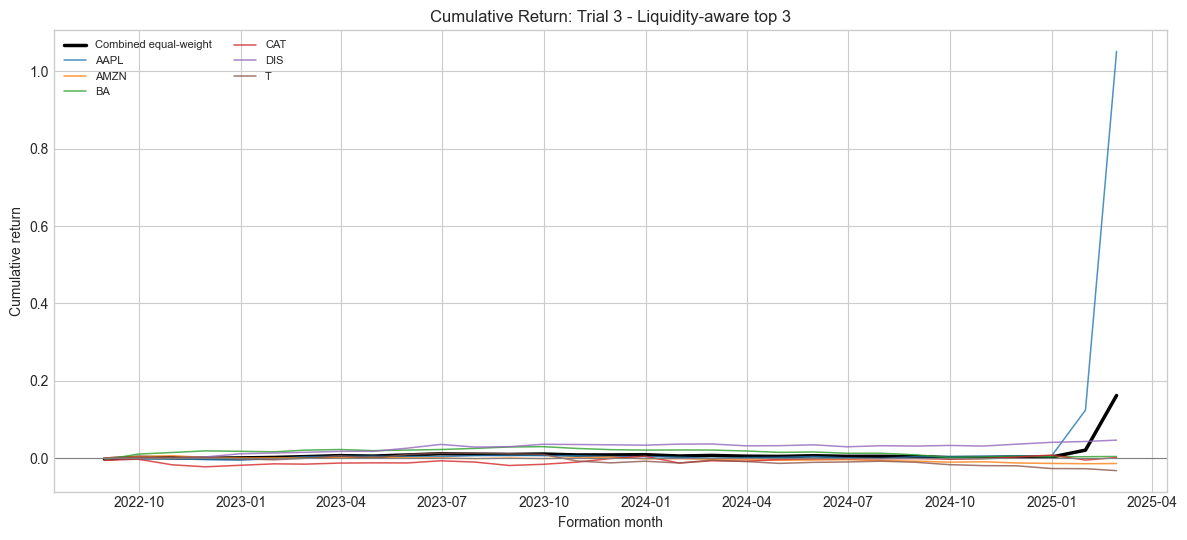

In [15]:
cumulative = combined_returns[["DATE", "portfolio_return"]].copy()
cumulative["combined"] = (1 + cumulative["portfolio_return"]).cumprod() - 1

issuer_cum = issuer_month_returns.pivot(index="DATE", columns="company_symbol", values="portfolio_return").sort_index()
issuer_cum = (1 + issuer_cum).cumprod() - 1

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(cumulative["DATE"], cumulative["combined"], color="black", linewidth=2.5, label="Combined equal-weight")
for issuer in issuer_cum.columns:
    ax.plot(issuer_cum.index, issuer_cum[issuer], linewidth=1.1, alpha=0.8, label=issuer)
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_title(f"Cumulative Return: {SELECTED_TRIAL}")
ax.set_xlabel("Formation month")
ax.set_ylabel("Cumulative return")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
plt.show()

## Turnover and DV01 Neutrality Checks

The first-order hedge is verified in both duration-contribution units and dollars of DV01 for `$1,000,000` gross capital. Values near zero are expected up to floating-point precision. Gross DV01 is nonzero; the purpose of the long-short scaling is to make the signed net DV01 approximately zero.

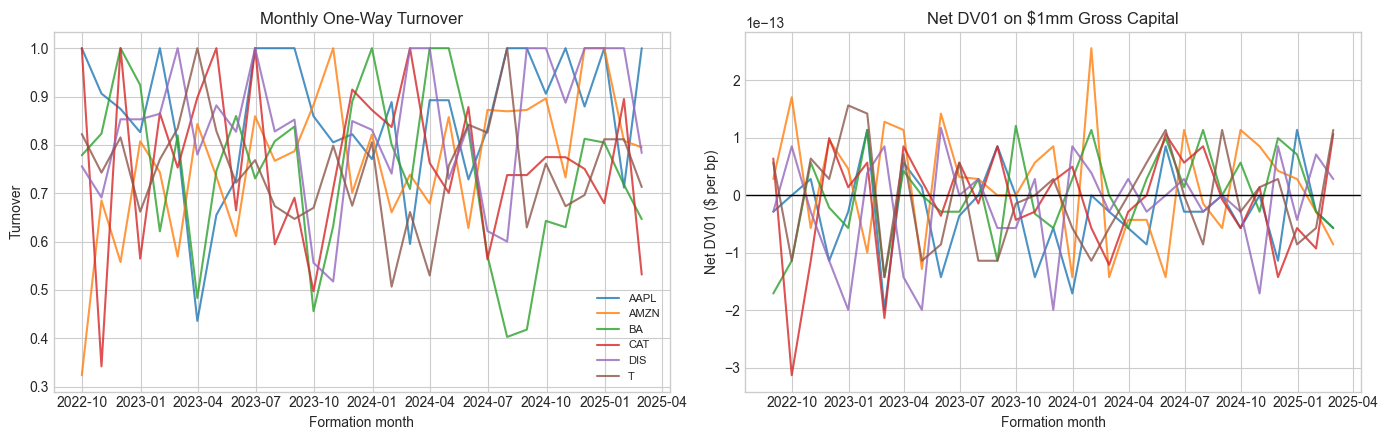

,max_abs_net_dv01_usd,avg_abs_net_dv01_usd,avg_gross_dv01_usd,avg_turnover
company_symbol,,,,
AAPL,$0.000000,$0.000000,"$1,426",0.86
AMZN,$0.000000,$0.000000,"$1,339",0.77
BA,$0.000000,$0.000000,$981,0.75
CAT,$0.000000,$0.000000,$998,0.77
DIS,$0.000000,$0.000000,"$1,133",0.84
T,$0.000000,$0.000000,"$1,058",0.75


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for issuer, g in issuer_month_returns.groupby("company_symbol"):
    axes[0].plot(g["DATE"], g["turnover"], alpha=0.8, label=issuer)
axes[0].set_title("Monthly One-Way Turnover")
axes[0].set_xlabel("Formation month")
axes[0].set_ylabel("Turnover")
axes[0].legend(fontsize=8)

for issuer, g in issuer_month_returns.groupby("company_symbol"):
    axes[1].plot(g["DATE"], g["net_dv01_usd"], alpha=0.8, label=issuer)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Net DV01 on $1mm Gross Capital")
axes[1].set_xlabel("Formation month")
axes[1].set_ylabel("Net DV01 ($ per bp)")

fig.tight_layout()
plt.show()

display(
    issuer_month_returns.groupby("company_symbol").agg(
        max_abs_net_dv01_usd=("net_dv01_usd", lambda x: x.abs().max()),
        avg_abs_net_dv01_usd=("net_dv01_usd", lambda x: x.abs().mean()),
        avg_gross_dv01_usd=("gross_dv01_usd", "mean"),
        avg_turnover=("turnover", "mean"),
    ).style.format({
        "max_abs_net_dv01_usd": "${:,.6f}", "avg_abs_net_dv01_usd": "${:,.6f}",
        "avg_gross_dv01_usd": "${:,.0f}", "avg_turnover": "{:.2f}",
    })
)

## Outlier Check

Professor Boroditsky discussed several reasons why a bond can look mispriced without offering a clean convergence trade: low liquidity, small issue size, age, coupon structure, optionality, seniority, and issuer-entity differences. The first table identifies bonds that appear repeatedly in the selected portfolio. The second compares those observations with bonds that were not selected.

This comparison is descriptive. If the cheap bonds are consistently smaller or less liquid, part of the residual may be compensation for trading difficulty rather than free alpha.

In [17]:
selection_review = (
    positions.assign(
        cheap_count=lambda x: (x["side"] == "long cheap").astype(int),
        rich_count=lambda x: (x["side"] == "short rich").astype(int),
        abs_resid_bps=lambda x: x["resid_bps"].abs(),
    )
    .groupby(["company_symbol", "CUSIP", "BOND_TYPE", "MATURITY", "COUPON"])
    .agg(
        times_selected=("ISSUE_ID", "size"),
        times_cheap=("cheap_count", "sum"),
        times_rich=("rich_count", "sum"),
        avg_duration=("DURATION", "mean"),
        avg_spread_bps=("T_Spread_bps", "mean"),
        avg_abs_resid_bps=("abs_resid_bps", "mean"),
        median_dvolume=("T_DVolume_num", "median"),
        median_amount_outstanding=("AMOUNT_OUTSTANDING", "median"),
        avg_bond_age_years=("bond_age_years", "mean"),
    )
    .reset_index()
    .sort_values(["times_selected", "avg_abs_resid_bps"], ascending=False)
    .head(20)
)
display(selection_review)

fitted_review = fitted[fitted["fit_ok"]].copy()
selected_keys = positions[["company_symbol", "DATE", "ISSUE_ID", "side"]].drop_duplicates()
fitted_review = fitted_review.merge(selected_keys, on=["company_symbol", "DATE", "ISSUE_ID"], how="left")
fitted_review["selection_group"] = fitted_review["side"].fillna("not selected")

characteristic_comparison = fitted_review.groupby("selection_group").agg(
    observations=("ISSUE_ID", "size"),
    median_abs_residual_bps=("resid_bps", lambda x: x.abs().median()),
    median_dollar_volume=("T_DVolume_num", "median"),
    median_amount_outstanding=("AMOUNT_OUTSTANDING", "median"),
    median_bond_age_years=("bond_age_years", "median"),
    median_duration=("DURATION", "median"),
    median_tmt=("TMT", "median"),
    median_coupon=("COUPON", "median"),
)
display(characteristic_comparison)

,company_symbol,CUSIP,BOND_TYPE,MATURITY,COUPON,times_selected,times_cheap,times_rich,avg_duration,avg_spread_bps,avg_abs_resid_bps,median_dvolume,median_amount_outstanding,avg_bond_age_years
51,AMZN,023135CK0,CDEB,2062-04-13,4.1000,21,12,9,17.2395,39.8095,12.2362,"78,112,968.0000","1,250,000.0000",1.5984
83,BA,097023CW3,CDEB,2050-05-01,5.8050,21,0,21,12.8257,20.8571,11.8276,"783,854,166.0000","5,500,000.0000",3.5372
50,AMZN,023135CJ3,CDEB,2052-04-13,3.9500,21,5,16,15.7210,29.2857,7.8069,"235,968,727.0000","2,500,000.0000",1.5310
196,T,00206RMT6,CDEB,2034-02-15,5.4000,20,0,20,7.4315,12.8000,12.3884,"830,164,165.5000","2,750,000.0000",0.9132
95,CAT,149123BN0,CDEB,2036-08-15,6.0500,19,16,3,8.8621,44.6316,24.0086,"15,590,008.0000","460,060.0000",17.3524
102,CAT,149123CJ8,CDEB,2050-04-09,3.2500,17,9,8,15.9841,37.8235,11.3302,"44,915,056.0000","1,200,000.0000",3.3510
94,CAT,149123BL4,CDEB,2035-09-15,5.3000,16,15,1,8.5388,43.1875,23.6879,"9,160,466.0000","307,320.0000",18.5878
98,CAT,149123CD1,CDEB,2044-05-15,4.3000,15,8,7,12.9540,40.0000,30.0960,"12,269,473.0000","500,000.0000",9.4668
148,DIS,254687FS0,CDEB,2050-03-23,4.7000,15,5,10,14.4193,31.2667,13.4823,"84,354,542.0000","1,750,000.0000",3.4940
37,AMZN,023135BJ4,CDEB,2047-08-22,4.0500,15,10,5,14.3487,37.5333,10.2495,"121,313,487.0000","3,487,493.0000",5.3109


,observations,median_abs_residual_bps,median_dollar_volume,median_amount_outstanding,median_bond_age_years,median_duration,median_tmt,median_coupon
selection_group,,,,,,,,
long cheap,558,22.3119,"35,557,574.0000","750,000.0000",5.4552,12.3200,18.9550,4.2000
not selected,6443,3.9493,"45,349,053.0000","1,000,000.0000",4.4162,6.8600,8.2400,3.6250
short rich,558,10.3933,"109,797,947.0000","1,750,000.0000",3.4442,13.2100,23.7500,4.1000


## What I Found

The final cell turns the main tables into a short written conclusion. I keep the three-test comparison, transaction costs, issuer concentration, and data limitations in the discussion so the result is not presented more strongly than the evidence supports.

In [18]:
combined = summary_table.loc["combined"]
baseline = trial_summary.loc["Trial 1 - Baseline top 3"]
concentrated = trial_summary.loc["Trial 2 - Concentrated top 2"]
liquidity_aware = trial_summary.loc["Trial 3 - Liquidity-aware top 3"]
best_issuer = issuer_summary["annualized_sharpe"].astype(float).idxmax()
worst_issuer = issuer_summary["annualized_sharpe"].astype(float).idxmin()
avg_net_dv01 = issuer_month_returns["net_dv01_usd"].abs().mean()
avg_turnover = issuer_month_returns["turnover"].mean()
ret_source_share = filtered["next_return_source"].value_counts(normalize=True).to_dict()
ret_eom_share = ret_source_share.get("RET_EOM", 0.0)
cost_25 = cost_sensitivity.loc["25 bps"]
without_aapl = robustness_table.loc["Excluding AAPL"]

outlier_liquidity = characteristic_comparison.loc[
    [x for x in ["long cheap", "short rich", "not selected"] if x in characteristic_comparison.index],
    "median_dollar_volume",
]
liquidity_sentence = "The outlier table gives a bond-level check on whether the signal is tied to liquidity."
if {"long cheap", "not selected"}.issubset(outlier_liquidity.index):
    direction = "lower" if outlier_liquidity["long cheap"] < outlier_liquidity["not selected"] else "higher"
    liquidity_sentence = f"The long-cheap observations have {direction} median dollar volume than the non-selected observations, so liquidity still appears to be part of the signal."

finding_text = f"""
### Summary Write-up

I analyzed AAPL, AMZN, BA, CAT, DIS, and T from {START_DATE} through {END_DATE}. For each issuer-month, I kept a common seniority and rating category. I also excluded defaulted and convertible bonds, required at least {MIN_TMT_YEARS:.0f} year to maturity, and required about ${MIN_AMOUNT_OUTSTANDING * 1_000 / 1_000_000:,.0f} million outstanding.

I fitted each issuer curve with log-duration, duration, and coupon. TRACE dollar volume and amount outstanding receive more weight because larger, actively traded issues generally give cleaner pricing observations. A positive fitting residual is treated as cheap and a negative residual as rich. {liquidity_sentence}

The three portfolio tests produced noticeably different results. The baseline top-three version earned {baseline['gross_annualized_return']:.2%} annualized before costs. Concentrating in the top two signals raised that figure to {concentrated['gross_annualized_return']:.2%}. The liquidity-aware top-three version earned {liquidity_aware['gross_annualized_return']:.2%} and had the strongest 25 bp cost-adjusted Sharpe ratio, so I use it as the final specification. This choice was made on the same data used for evaluation, which means the reported winner is subject to selection bias.

For the selected portfolio, gross total return is {combined['total_return']:.2%}, annualized return is {combined['annualized_return']:.2%}, annualized volatility is {combined['annualized_volatility']:.2%}, and annualized Sharpe ratio is {combined['annualized_sharpe']:.2f}. The average one-way monthly turnover is {avg_turnover:.2f}. With a 25 bp one-way cost, annualized return falls to {cost_25['annualized_return']:.2%} and Sharpe falls to {cost_25['annualized_sharpe']:.2f}. On the $1 million gross-capital convention, the sum of monthly gross PnL is ${combined['total_pnl_usd']:,.0f}.

The DV01 hedge works mechanically: average absolute net DV01 is ${avg_net_dv01:,.6f} per basis point. The return is less broad than the headline number suggests. When AAPL is removed, annualized return falls to {without_aapl['annualized_return']:.2%} and Sharpe falls to {without_aapl['annualized_sharpe']:.2f}. Among the six issuers, {best_issuer} has the strongest result and {worst_issuer} the weakest.

{ret_eom_share:.1%} of filtered bond-month observations have a valid next-month WRDS `RET_EOM`. The price-plus-accrual fallback was available but was not needed in this sample. I view the backtest as evidence that construction choices matter, not as a fully tradable strategy. Bid-offer spreads, financing, borrow availability, fill probability, call features, and point-in-time data delays are not completely modeled.
"""

display(Markdown(finding_text))


### Summary Write-up

I analyzed AAPL, AMZN, BA, CAT, DIS, and T from 2022-08-31 through 2025-03-31. For each issuer-month, I kept a common seniority and rating category. I also excluded defaulted and convertible bonds, required at least 1 year to maturity, and required about $200 million outstanding.

I fitted each issuer curve with log-duration, duration, and coupon. TRACE dollar volume and amount outstanding receive more weight because larger, actively traded issues generally give cleaner pricing observations. A positive fitting residual is treated as cheap and a negative residual as rich. The long-cheap observations have lower median dollar volume than the non-selected observations, so liquidity still appears to be part of the signal.

The three portfolio tests produced noticeably different results. The baseline top-three version earned 2.75% annualized before costs. Concentrating in the top two signals raised that figure to 4.48%. The liquidity-aware top-three version earned 5.99% and had the strongest 25 bp cost-adjusted Sharpe ratio, so I use it as the final specification. This choice was made on the same data used for evaluation, which means the reported winner is subject to selection bias.

For the selected portfolio, gross total return is 16.21%, annualized return is 5.99%, annualized volatility is 8.66%, and annualized Sharpe ratio is 0.69. The average one-way monthly turnover is 0.79. With a 25 bp one-way cost, annualized return falls to 3.60% and Sharpe falls to 0.42. On the $1 million gross-capital convention, the sum of monthly gross PnL is $159,240.

The DV01 hedge works mechanically: average absolute net DV01 is $0.000000 per basis point. The return is less broad than the headline number suggests. When AAPL is removed, annualized return falls to 0.05% and Sharpe falls to 0.06. Among the six issuers, DIS has the strongest result and AMZN the weakest.

95.6% of filtered bond-month observations have a valid next-month WRDS `RET_EOM`. The price-plus-accrual fallback was available but was not needed in this sample. I view the backtest as evidence that construction choices matter, not as a fully tradable strategy. Bid-offer spreads, financing, borrow availability, fill probability, call features, and point-in-time data delays are not completely modeled.


## Main Assumptions and Limitations

- **Return measure:** I use WRDS `RET_EOM` as the monthly total return. The fallback adds clean-price return and accrued coupon using actual gap days over 360, but it does not rebuild the full coupon schedule.
- **Timing:** I assume the month-end fields were available when the position was formed. Publication delays and later revisions are not modeled.
- **Curve model:** the three-factor regression is transparent and matches the assignment, but it is not a full Nelson-Siegel cash-flow model and does not rebuild the Treasury zero curve.
- **Bond features:** I control for seniority, rating, default status, convertibility, maturity, and issue size. Complete call schedules, 144A status, subsidiary distinctions, insurance, and step-up coupons are not available in the supplied files.
- **Risk hedge:** the portfolio neutralizes first-order parallel-rate DV01. It can still carry Treasury-curve slope and curvature risk, spread-duration risk, issuer beta, downgrade risk, and liquidity exposure.
- **Trading costs:** the turnover-based cost cases are approximations. Actual bid-offer spreads, market impact, financing, borrow fees, and failed fills may be higher and may differ between buys and shorts.
- **Model selection:** I tested three portfolio rules and selected the best one on this sample. That improves the in-sample result but introduces selection bias. A cleaner test would choose the rule on an earlier training period and evaluate it on later data.
- **Issuer concentration:** the robustness check shows that AAPL contributes a large share of the selected portfolio's return.
- **Shorting:** some corporate bonds are expensive or impossible to borrow. The long-short backtest is a research exercise, not proof that every trade could have been executed.